In [1]:
from interfaces.control_socket_client import ControlSocketClient
from interfaces.device_socket_client import DeviceSocketClient
from interfaces.config_socket_client import ConfigSocketClient
from interfaces.rtde_socket_client import RTDESocketClient
from utils.record_plot import PlotTool

import common as common
import time

import keyboard
from IPython.display import clear_output

import math
import matplotlib.pyplot as plt
import numpy as np

from scipy.spatial import ConvexHull

ip = '192.168.0.105'
control = ControlSocketClient(ip)
device = DeviceSocketClient(ip)
config = ConfigSocketClient(ip)
rtde = RTDESocketClient(ip)

plot = PlotTool(control)

# 1번 템플릿: 꺾은 직선 (2D, 회전 고정)

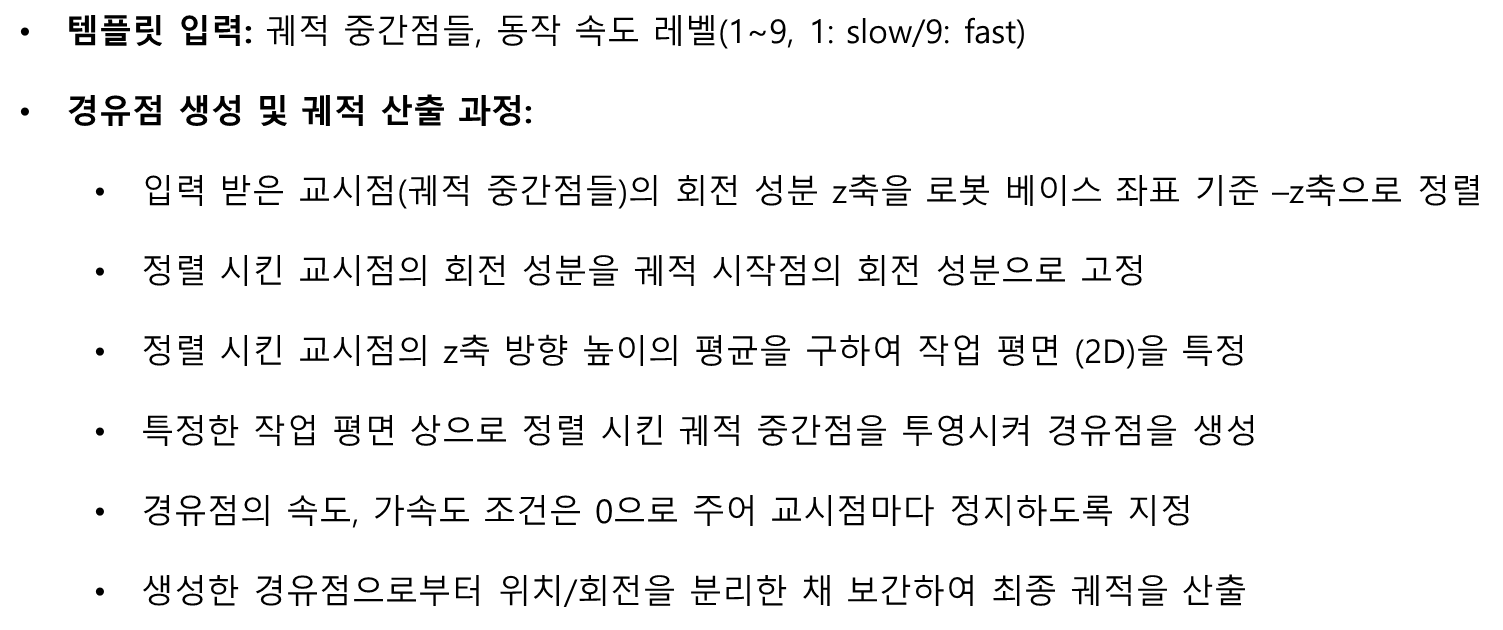

In [2]:
num = 4 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [3]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [13]:
print("궤적 중간점들 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

궤적 중간점들 입력
Press '5' button to get pos

points0 : [-428.75723, 136.9486, 525.2095, -178.98209, -0.98695314, 179.9942]

points1 : [-515.5765, 136.95224, 525.2169, -178.98323, -0.9860705, 179.99277]

points2 : [-515.5777, 68.11759, 525.2161, -178.98329, -0.9862632, 179.9906]

points3 : [-429.94482, 68.116425, 525.21576, -178.98251, -0.98715466, 179.99199]



In [14]:
# 정렬 시킨 교시점의 회전 성분을 궤적 시작점의 회전 성분으로 고정
print(points[0])
for i in range (1,num):
    for j in range(3,6):
        points[i][j] = points[0][j]
    print(points[i])

[-428.75723, 136.9486, 525.2095, -178.98209, -0.98695314, 179.9942]
[-515.5765, 136.95224, 525.2169, -178.98209, -0.98695314, 179.9942]
[-515.5777, 68.11759, 525.2161, -178.98209, -0.98695314, 179.9942]
[-429.94482, 68.116425, 525.21576, -178.98209, -0.98695314, 179.9942]


In [15]:
#정렬 시킨 교시점의 z축 방향 높이의 평균을 구하여 작업 평면 (2D)을 특정
sum = 0
for i in range (num):
    sum += points[i][2]
avg = sum/num
print(avg)

525.214565


In [16]:
for i in range(num):
    points[i][2] = avg 
    print(points[i])

[-428.75723, 136.9486, 525.214565, -178.98209, -0.98695314, 179.9942]
[-515.5765, 136.95224, 525.214565, -178.98209, -0.98695314, 179.9942]
[-515.5777, 68.11759, 525.214565, -178.98209, -0.98695314, 179.9942]
[-429.94482, 68.116425, 525.214565, -178.98209, -0.98695314, 179.9942]


In [22]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)

plot.start_log()
for i in range(num):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)

In [23]:
plot.end_log()

In [24]:
file_name = 'RTRecord.csv'
plot.load_data_6dof(ip, file_name)

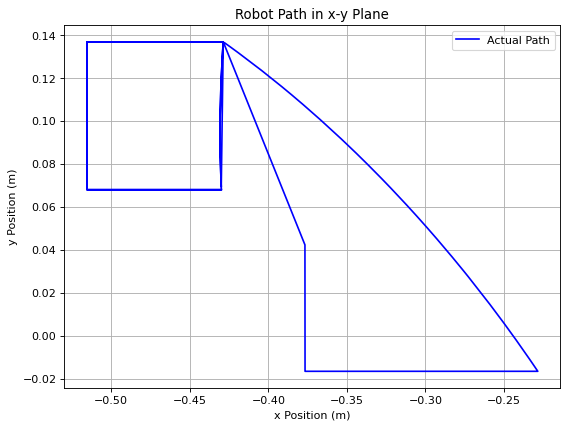

In [26]:
plot.plot_robot_path()


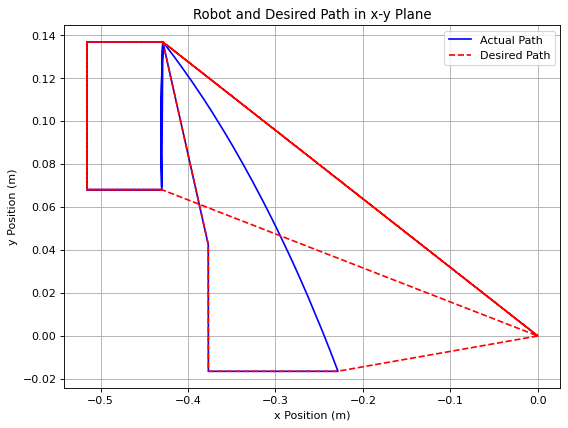

In [25]:
plot.plot_robot_and_desired_path()


# 2번 템플릿: 꺾은 직선 (2D, 회전 포함)

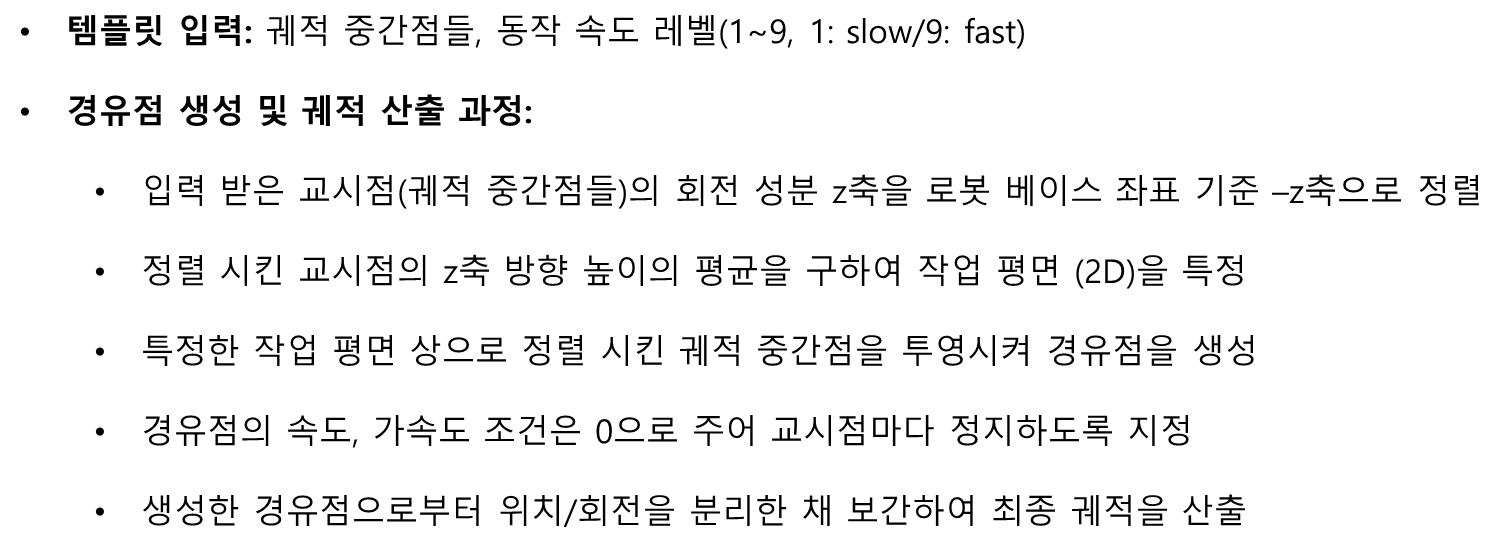

In [177]:
num = 4 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 #동작 속도 레벨


points = [0]*num
points_inverZ = [0]*num

In [178]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [179]:
print("궤적 중간점들 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")


Press '5' button to get pos

points0 : [-426.08768, 189.55618, 454.77255, 1.0147141, -179.03992, 0.042221364]

points1 : [-469.73453, 2.196743, 520.87573, -11.267708, 175.30104, 29.987421]

points2 : [-353.6106, -204.24698, 480.85513, -8.84114, -165.74768, 48.196217]

points3 : [-499.21777, -326.14697, 328.8276, 14.446667, 178.79016, 57.07494]



In [180]:
#정렬 시킨 교시점의 z축 방향 높이의 평균을 구하여 작업 평면 (2D)을 특정
sum = 0
for i in range (num):
    sum += points[i][2]
avg = sum/num
print(avg)

446.3327525


In [181]:
for i in range(num):
    points[i][2] = avg 
    print(points[i])

[-426.08768, 189.55618, 446.3327525, 1.0147141, -179.03992, 0.042221364]
[-469.73453, 2.196743, 446.3327525, -11.267708, 175.30104, 29.987421]
[-353.6106, -204.24698, 446.3327525, -8.84114, -165.74768, 48.196217]
[-499.21777, -326.14697, 446.3327525, 14.446667, 178.79016, 57.07494]


In [182]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(num):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)


aa
bb0
bb1
bb2
bb3


# 3번 템플릿: 정다각형 (2D)

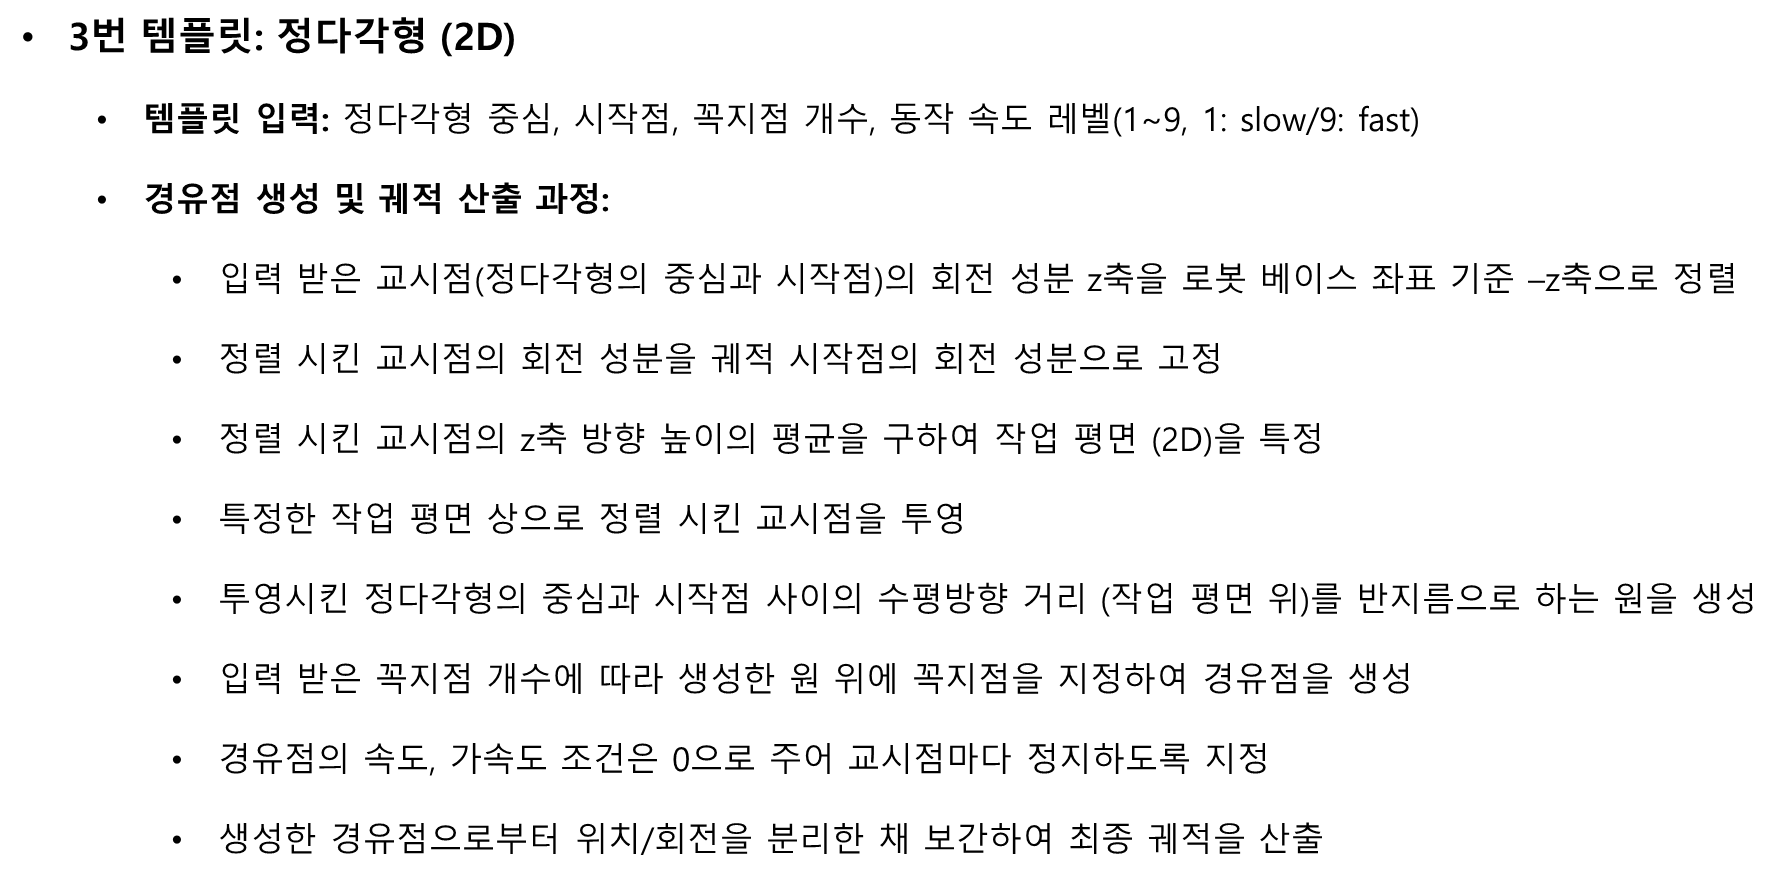

In [40]:
num = 4 # 꼭지점 개수 입력
vel_ratio = 25 # 동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [41]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [42]:
def calculate_polygon_vertices(center, start_point, vertices, radius, start_angle):
    # 중심점
    cx, cy, cz, cu, cv, cw = center

    # 시작점
    sx, sy, sz, su, sv, sw = start_point

    # 중심점과 시작점의 z축 방향 높이의 평균
    average_height = (cz + sz) / 2.0
    
    # Calculate the angle increment for each vertex
    angle_increment = 2 * np.pi / vertices

    # 정다각형의 꼭지점 좌표 계산ㅃ
    polygon_vertices = []
    for i in range(vertices):
        angle = start_angle + i * angle_increment
        x = cx + radius * np.cos(angle)
        y = cy + radius * np.sin(angle)
        # Z 좌표를 z축 방향 높이의 평균으로 고정
        z = average_height
        # 회전 성분을 궤적 시작점의 회전 성분으로 고정
        vertex = [x, y, z, su, sv, sw]
        polygon_vertices.append(vertex)

    return polygon_vertices

In [43]:
print("중심점과 시작점")
print("Press '5' button to get pos\n")
for i in range (2):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos() 
    if i == 1: #다각형 시작점 joint pos 구하기.
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")


중심점과 시작점
Press '5' button to get pos

points0 : [-343.39224, -160.87146, 525.2036, -178.98695, -0.9852283, 179.99059]

points1 : [-464.40005, -160.86871, 525.2056, -178.98804, -0.98481673, 179.99059]



In [44]:
target_pos = calculate_polygon_vertices(points[0], points[1], num, 1, 0)
print(target_pos)

[[-342.39224, -160.87146, 525.2046, -178.98804, -0.98481673, 179.99059], [-343.39224, -159.87146, 525.2046, -178.98804, -0.98481673, 179.99059], [-344.39224, -160.87146, 525.2046, -178.98804, -0.98481673, 179.99059], [-343.39224, -161.87146, 525.2046, -178.98804, -0.98481673, 179.99059]]


In [46]:
target_pos

[[-342.39224, -160.87146, 525.2046, -178.98804, -0.98481673, 179.99059],
 [-343.39224, -159.87146, 525.2046, -178.98804, -0.98481673, 179.99059],
 [-344.39224, -160.87146, 525.2046, -178.98804, -0.98481673, 179.99059],
 [-343.39224, -161.87146, 525.2046, -178.98804, -0.98481673, 179.99059]]

In [45]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(num):
    control.MoveL(tpos=target_pos[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)
control.MoveL(tpos=target_pos[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)

{'msg': 'MoveL Success', 'code': '0'}

# 4번 템플릿: 최대볼록다각형 (2D)

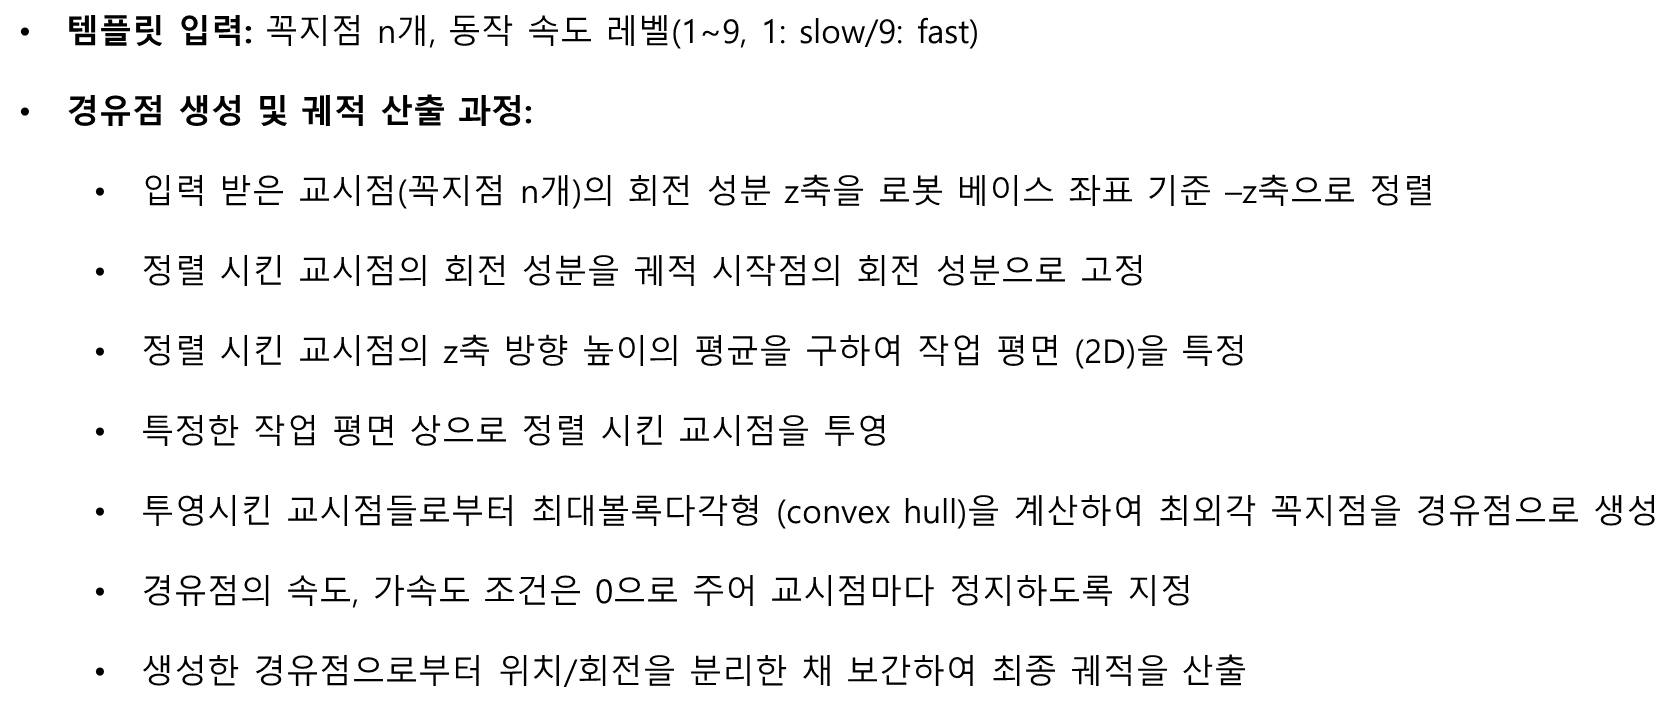

In [2]:
vel_ratio = 25 # 동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = []

In [3]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos#, target_pos_inverZ

In [4]:
def calculate_convex_hull(points):
    # Convex Hull을 계산하여 좌표를 얻는 함수
    hull = ConvexHull(points)
    sorted_points = hull.points[hull.vertices]
    return sorted_points

def sort_convex_hull_points(convex_hull_points):
    # 최대볼록다각형 좌표를 순서대로 정렬하는 함수
    center = np.mean(convex_hull_points, axis=0)
    angles = np.arctan2(convex_hull_points[:, 1] - center[1], convex_hull_points[:, 0] - center[0])
    sorted_indices = np.argsort(angles)
    sorted_points = convex_hull_points[sorted_indices]
    return sorted_points

In [5]:
print("교시점 입력")
print("Press '5' button to get pos")
print("Press 'q' button to quit pos input\n")

i = 0
while True:
    time.sleep(0.5)
    if keyboard.is_pressed("q"):
        print("quit to save points")
        break
    elif keyboard.is_pressed("5"):
        points.append(get_pos()) 
        print(f"points{i} : {points[i]}\n")
        i += 1


교시점 입력
Press '5' button to get pos
Press 'q' button to quit pos input

points0 : [-187.38, 349.52402, 521.9435, -179.95076, 20.01212, 90.16315]

points1 : [-322.14517, 348.9409, 521.6169, -179.95963, 20.050182, 90.29284]

points2 : [-321.8515, 233.1858, 521.4494, -157.74648, 18.547325, 97.68393]

points3 : [-164.43578, 305.18088, 431.58014, -157.76791, 18.608086, 97.36975]

points4 : [-164.34052, 429.36978, 426.39423, -157.78752, 18.595629, 70.15539]

points5 : [-28.397348, 429.43524, 426.3332, -157.78223, 18.61491, 70.02691]

points6 : [-28.396177, 429.43683, 426.33347, -157.78232, 18.614603, 70.02697]

points7 : [-436.038, 381.06476, 378.94894, -157.83821, 18.681297, 92.191986]

points8 : [-435.11786, 328.36047, 377.4537, 170.84622, -24.861166, 105.92503]

points9 : [-433.3381, 287.71518, 611.74005, 170.7816, -24.769825, 105.99858]

quit to save points


In [6]:

# 높이 평균 계산
avg_height = np.mean([point[2] for point in points])

# 작업평면 특정
projected_points = np.array([[point[0], point[1]] for point in points])

# 최대볼록다각형 계산
convex_hull_points = calculate_convex_hull(projected_points)

# 최대볼록다각형 좌표 정렬
sorted_convex_hull_points = sort_convex_hull_points(convex_hull_points)

# 결과 출력
target_pos = []
print(sorted_convex_hull_points)
print("\n최대볼록다각형 좌표:")
for i, point in enumerate(sorted_convex_hull_points):
    target_pos.append([point[0], point[1], avg_height, points[0][3], points[0][4], points[0][5]])

print(target_pos)


[[-435.11786   328.36047 ]
 [-433.3381    287.71518 ]
 [-321.8515    233.1858  ]
 [-164.43578   305.18088 ]
 [ -28.397348  429.43524 ]
 [ -28.396177  429.43683 ]
 [-164.34052   429.36978 ]
 [-436.038     381.06476 ]]

최대볼록다각형 좌표:
[[-435.11786, 328.36047, 464.379353, -179.95076, 20.01212, 90.16315], [-433.3381, 287.71518, 464.379353, -179.95076, 20.01212, 90.16315], [-321.8515, 233.1858, 464.379353, -179.95076, 20.01212, 90.16315], [-164.43578, 305.18088, 464.379353, -179.95076, 20.01212, 90.16315], [-28.397348, 429.43524, 464.379353, -179.95076, 20.01212, 90.16315], [-28.396177, 429.43683, 464.379353, -179.95076, 20.01212, 90.16315], [-164.34052, 429.36978, 464.379353, -179.95076, 20.01212, 90.16315], [-436.038, 381.06476, 464.379353, -179.95076, 20.01212, 90.16315]]


In [24]:
init_jpos = control.Calculate_IK(target_pos[0],rtde.GetControlData()['q']) # joint pos)
print(init_jpos['jpos'])
control.MoveJ(jpos=init_jpos['jpos'], blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(len(target_pos)):
    control.MoveL(tpos=target_pos[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)
control.MoveL(tpos=target_pos[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)


[-61.033432, 28.58793, 69.130775, 9.677308, 99.81988, 28.99207]


{'msg': 'MoveL Success', 'code': '0'}

# 5번 템플릿: 원형 나선 궤적 (2D)

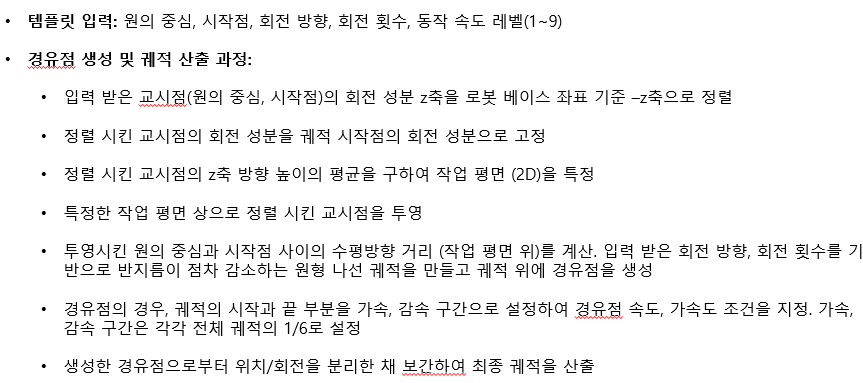

# 6번 템플릿: 원 (2D)

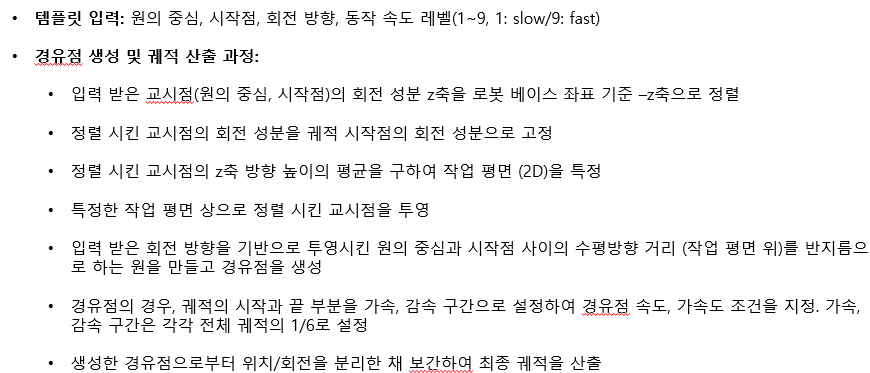

# 9번 템플릿: 평행사변형 (2D)

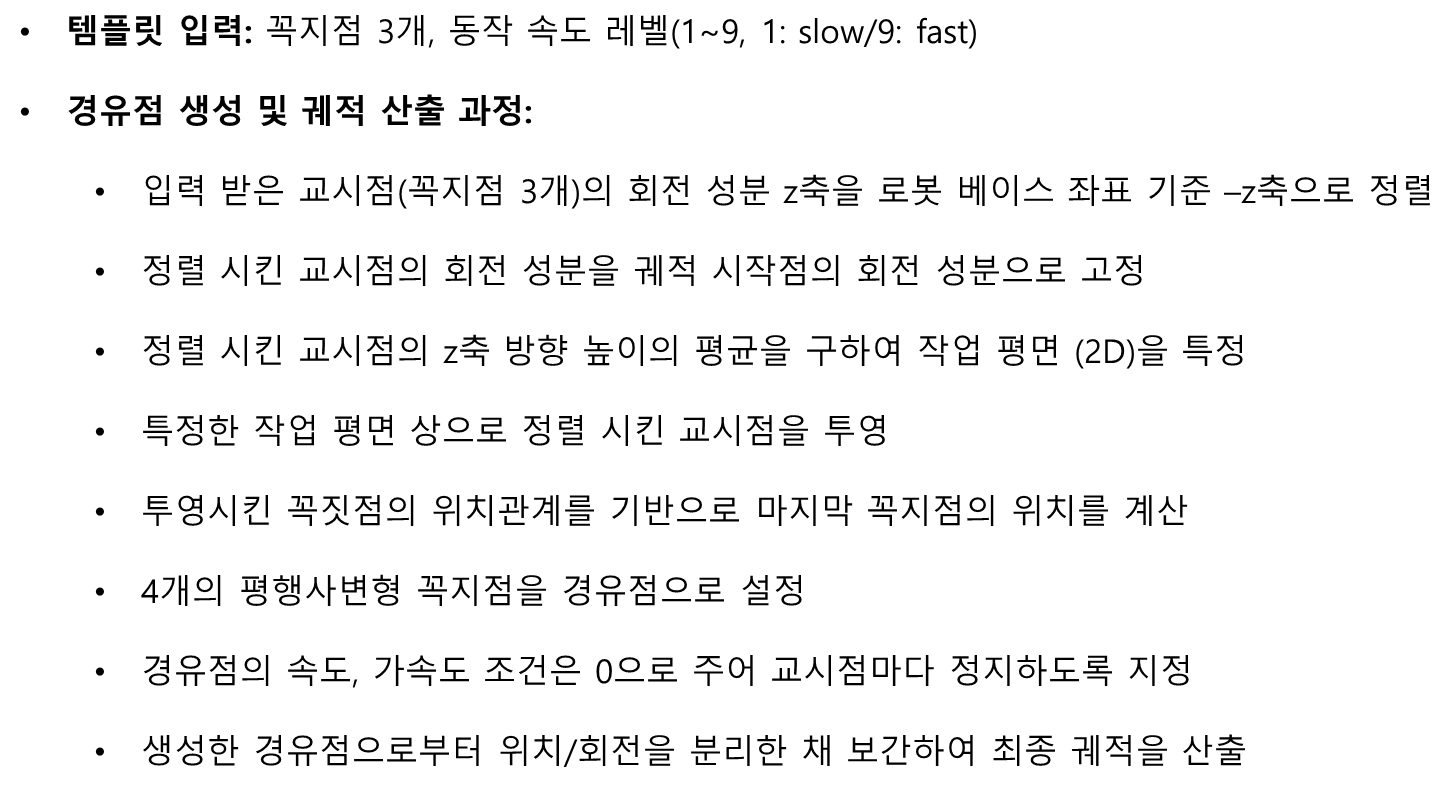

In [132]:
num = 3 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [133]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [134]:
def find_parallelogram_vertex(points):
    # A, B, C를 벡터로 변환
    AB_vector = [points[1][0] - points[0][0], points[1][1] - points[0][1]]
    BC_vector = [points[2][0] - points[1][0], points[2][1] - points[1][1]]

    # BC 벡터를 A에 더해서 D를 구함
    D = [points[0][0] + BC_vector[0], points[0][1] + BC_vector[1]]

    return D

In [135]:
print("3개 꼭지점 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

3개 꼭지점 입력
Press '5' button to get pos

points0 : [-358.3974, -196.81552, 525.19904, -178.98439, -0.9864535, 179.99388]

points1 : [-413.82883, -196.81444, 525.1997, -178.98488, -0.98635745, 179.99405]

points2 : [-413.82895, -286.05307, 525.1999, -178.98506, -0.9863379, 179.9935]



In [136]:
# 정렬 시킨 교시점의 회전 성분을 궤적 시작점의 회전 성분으로 고정
print(points[0])
for i in range (1,num):
    for j in range(3,6):
        points[i][j] = points[0][j]
    print(points[i])

[-358.3974, -196.81552, 525.19904, -178.98439, -0.9864535, 179.99388]
[-413.82883, -196.81444, 525.1997, -178.98439, -0.9864535, 179.99388]
[-413.82895, -286.05307, 525.1999, -178.98439, -0.9864535, 179.99388]


In [137]:
#정렬 시킨 교시점의 z축 방향 높이의 평균을 구하여 작업 평면 (2D)을 특정
sum = 0
for i in range (num):
    sum += points[i][2]
avg = sum/num
print(avg)

for i in range(num):
    points[i][2] = avg 
    print(points[i])

525.1995466666667
[-358.3974, -196.81552, 525.1995466666667, -178.98439, -0.9864535, 179.99388]
[-413.82883, -196.81444, 525.1995466666667, -178.98439, -0.9864535, 179.99388]
[-413.82895, -286.05307, 525.1995466666667, -178.98439, -0.9864535, 179.99388]


In [138]:
# 꼭지점 D 계산
D = find_parallelogram_vertex(points)

points.append(D+points[0][2:6])
print(points)


[[-358.3974, -196.81552, 525.1995466666667, -178.98439, -0.9864535, 179.99388], [-413.82883, -196.81444, 525.1995466666667, -178.98439, -0.9864535, 179.99388], [-413.82895, -286.05307, 525.1995466666667, -178.98439, -0.9864535, 179.99388], [-358.39752000000004, -286.05415, 525.1995466666667, -178.98439, -0.9864535, 179.99388]]


In [139]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
plot.start_log()
for i in range(num+1):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)
control.MoveL(tpos=points[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)    

{'msg': 'MoveL Success', 'code': '0'}

In [140]:
plot.end_log()

In [82]:
print("111")

111


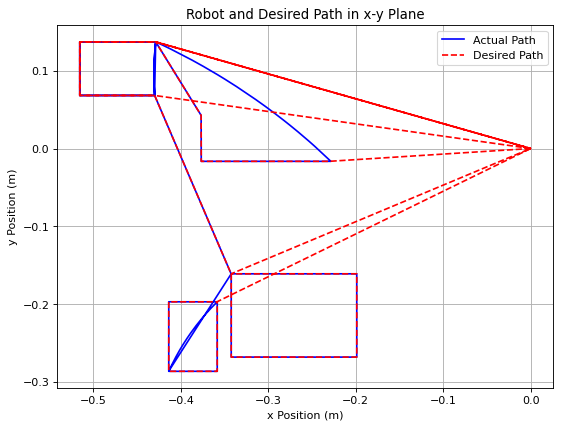

In [141]:
file_name = 'RTRecord.csv'
plot.load_data_6dof(ip, file_name)
plot.plot_robot_and_desired_path()


# 10번 템플릿: 왕복 직선 궤적 (2D)

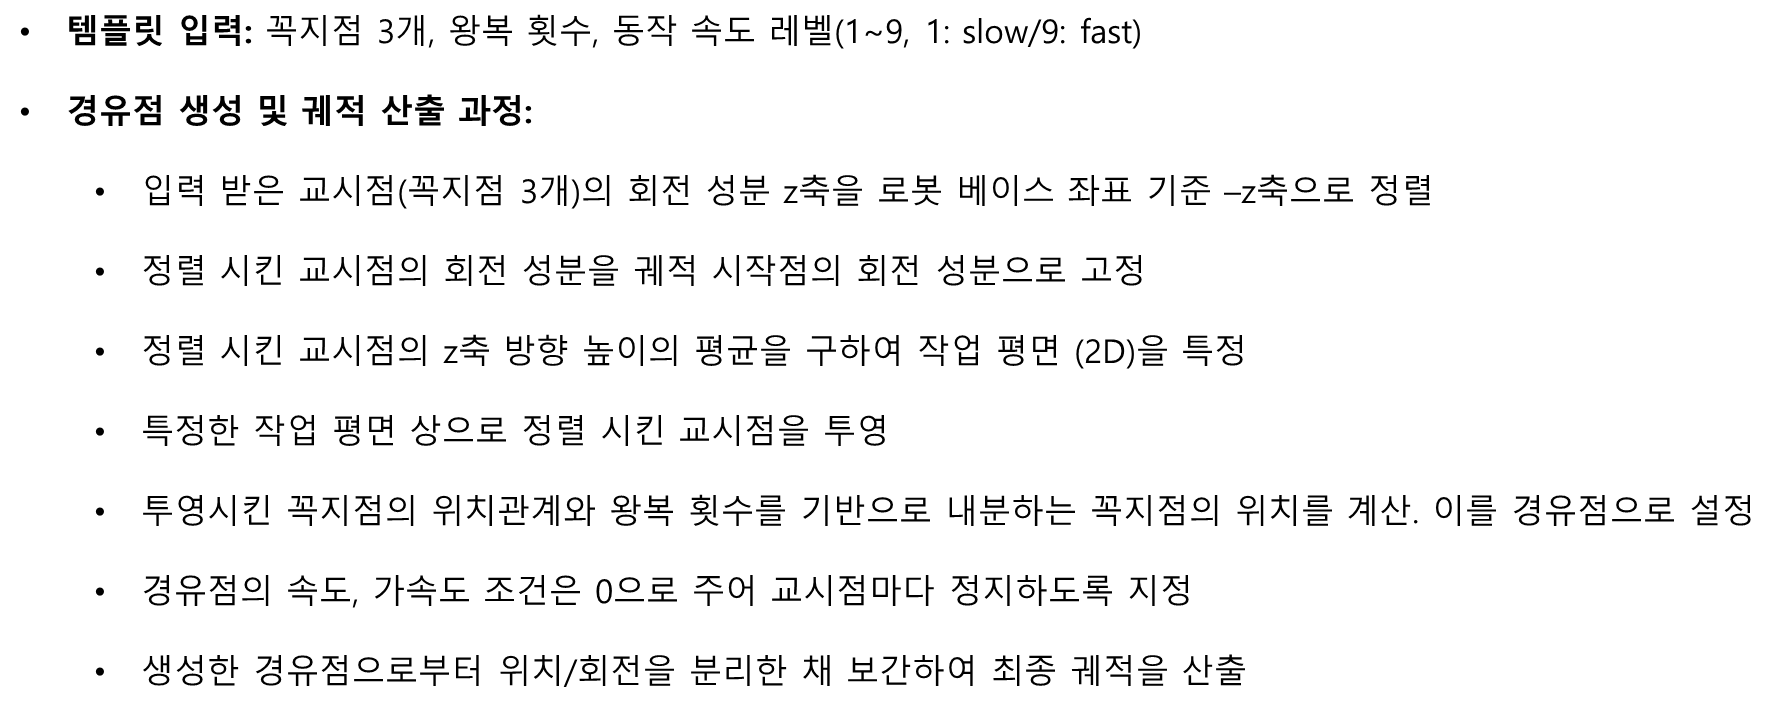

In [12]:
num = 3 # 교시점 갯수 입력
repeat_num = 3 #왕복 횟수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [13]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [14]:
def divide_segment(point1, point2, division_points):
    divided_points = []
    for i in range(division_points + 1):
        x = point1[0] + i * (point2[0] - point1[0]) / division_points
        y = point1[1] + i * (point2[1] - point1[1]) / division_points
        divided_points.append((x, y))
    return divided_points

def find_parallelogram_vertex(points, division_points):
    # A, B, C를 벡터로 변환
    AB_vector = [points[1][0] - points[0][0], points[1][1] - points[0][1]]
    BC_vector = [points[2][0] - points[1][0], points[2][1] - points[1][1]]

    # BC 벡터를 A에 더해서 D를 구함
    D = [points[0][0] + BC_vector[0], points[0][1] + BC_vector[1]]

    # AD 선분을 균일하게 등분
    divided_points_AD = divide_segment(points[0], D, division_points)

    # BC 선분을 균일하게 등분
    divided_points_BC = divide_segment(points[1], points[2], division_points)

    return divided_points_AD, divided_points_BC

def generate_target_positions(divided_points_AD, divided_points_BC, repeat_num):
    target_pos = []

    for i in range(2*repeat_num+1):
        if i%2 == 0:
            target_pos.append(divided_points_AD[i])
            target_pos.append(divided_points_BC[i])
        else :
            target_pos.append(divided_points_BC[i])
            target_pos.append(divided_points_AD[i])
            
    return target_pos

In [15]:
print("3개 꼭지점 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

3개 꼭지점 입력
Press '5' button to get pos

points0 : [-94.17791, 380.54068, 433.7417, 162.05702, 0.5513976, 90.02372]

points1 : [-347.42862, 379.71994, 433.23874, 162.0275, 0.6151409, 90.16229]

points2 : [-347.26132, 515.0565, 326.38898, 151.77667, 0.7752909, 90.0348]



In [16]:
# 정렬 시킨 교시점의 회전 성분을 궤적 시작점의 회전 성분으로 고정
print(points[0])
for i in range (1,num):
    for j in range(3,6):
        points[i][j] = points[0][j]
    print(points[i])

[-94.17791, 380.54068, 433.7417, 162.05702, 0.5513976, 90.02372]
[-347.42862, 379.71994, 433.23874, 162.05702, 0.5513976, 90.02372]
[-347.26132, 515.0565, 326.38898, 162.05702, 0.5513976, 90.02372]


In [17]:
#정렬 시킨 교시점의 z축 방향 높이의 평균을 구하여 작업 평면 (2D)을 특정
sum = 0
for i in range (num):
    sum += points[i][2]
avg = sum/num
print(avg)

for i in range(num):
    points[i][2] = avg 
    print(points[i])

397.78980666666666
[-94.17791, 380.54068, 397.78980666666666, 162.05702, 0.5513976, 90.02372]
[-347.42862, 379.71994, 397.78980666666666, 162.05702, 0.5513976, 90.02372]
[-347.26132, 515.0565, 397.78980666666666, 162.05702, 0.5513976, 90.02372]


In [18]:
# AD, BC 선분을 등분할 점의 개수
if repeat_num == 0:
    division_points = 1
else:
    division_points = 2*repeat_num

# 등분된 점들 계산
divided_points_AD, divided_points_BC = find_parallelogram_vertex(points, division_points)

print(f"The divided points on AD segment are: {divided_points_AD}")
print(f"The divided points on BC segment are: {divided_points_BC}")


The divided points on AD segment are: [(-94.17791, 380.54068), (-94.15002666666666, 403.0967733333333), (-94.12214333333333, 425.6528666666667), (-94.09425999999999, 448.20896000000005), (-94.06637666666666, 470.76505333333336), (-94.03849333333332, 493.32114666666666), (-94.01060999999999, 515.87724)]
The divided points on BC segment are: [(-347.42862, 379.71994), (-347.4007366666667, 402.2760333333333), (-347.37285333333335, 424.8321266666667), (-347.34497, 447.38822000000005), (-347.3170866666667, 469.94431333333335), (-347.2892033333334, 492.50040666666666), (-347.26132, 515.0565)]


In [19]:
if repeat_num == 0:
    points.append(list(divided_points_AD[1]) + points[0][2:6])
    target_pos = points
else:
    target_pos = generate_target_positions(divided_points_AD, divided_points_BC, repeat_num)

print(f"The target positions are: {target_pos}")


The target positions are: [(-94.17791, 380.54068), (-347.42862, 379.71994), (-347.4007366666667, 402.2760333333333), (-94.15002666666666, 403.0967733333333), (-94.12214333333333, 425.6528666666667), (-347.37285333333335, 424.8321266666667), (-347.34497, 447.38822000000005), (-94.09425999999999, 448.20896000000005), (-94.06637666666666, 470.76505333333336), (-347.3170866666667, 469.94431333333335), (-347.2892033333334, 492.50040666666666), (-94.03849333333332, 493.32114666666666), (-94.01060999999999, 515.87724), (-347.26132, 515.0565)]


In [20]:
for i in range(len(target_pos)):
    target_pos[i] = list(target_pos[i])+points[0][2:6]
print(target_pos)

[[-94.17791, 380.54068, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.42862, 379.71994, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.4007366666667, 402.2760333333333, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-94.15002666666666, 403.0967733333333, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-94.12214333333333, 425.6528666666667, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.37285333333335, 424.8321266666667, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.34497, 447.38822000000005, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-94.09425999999999, 448.20896000000005, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-94.06637666666666, 470.76505333333336, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.3170866666667, 469.94431333333335, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-347.2892033333334, 492.50040666666666, 397.78980666666666, 162.05702, 0.5513976, 90.02372], [-94.038493

In [21]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(len(target_pos)):
    control.MoveL(tpos=target_pos[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)

# 11번 템플릿: 교시점을 지나는 꺾은 선 (교시점마다 정지, 회전 고정)

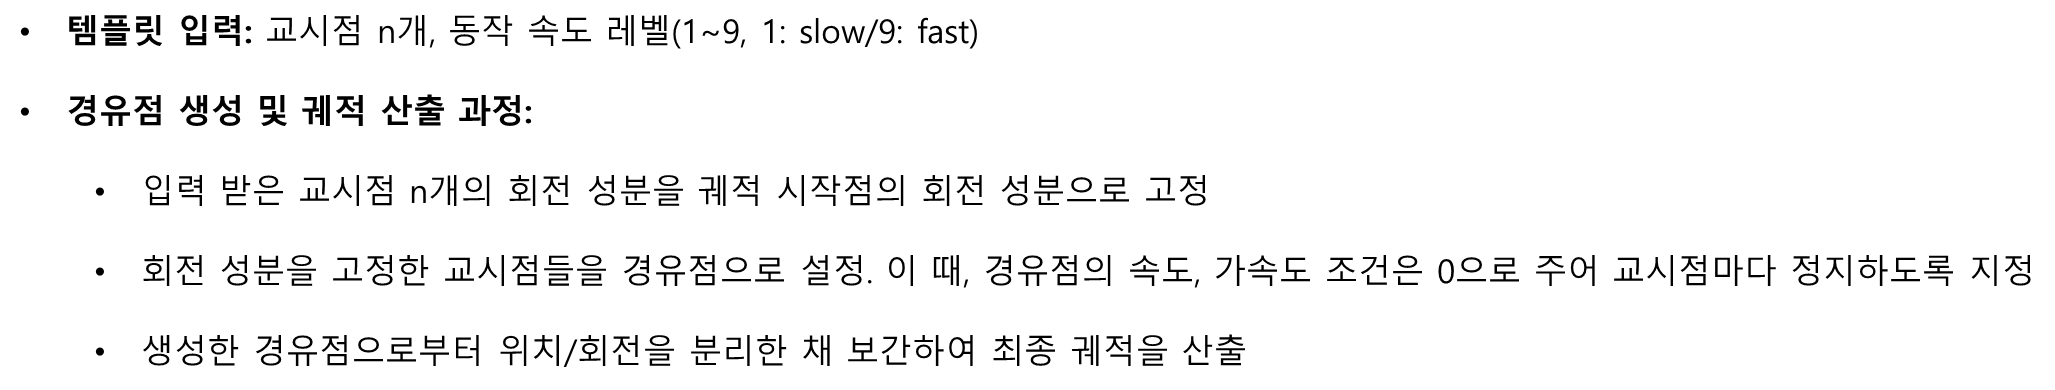

In [22]:
num = 4 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [23]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [24]:
print("궤적 중간점들 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

궤적 중간점들 입력
Press '5' button to get pos

points0 : [-185.87294, 350.0934, 522.1707, 179.99765, -0.034792397, 89.91077]

points1 : [-415.79572, 228.68912, 435.80972, -169.00896, 19.074198, 122.82217]

points2 : [-474.3304, 455.82434, 392.22714, -177.57019, -30.41849, 115.142105]

points3 : [-118.785904, 419.55698, 379.89783, 143.36252, 9.151293, 100.23981]



In [25]:
# 정렬 시킨 교시점의 회전 성분을 궤적 시작점의 회전 성분으로 고정
print(points[0])
for i in range (1,num):
    for j in range(3,6):
        points[i][j] = points[0][j]
    print(points[i])

[-185.87294, 350.0934, 522.1707, 179.99765, -0.034792397, 89.91077]
[-415.79572, 228.68912, 435.80972, 179.99765, -0.034792397, 89.91077]
[-474.3304, 455.82434, 392.22714, 179.99765, -0.034792397, 89.91077]
[-118.785904, 419.55698, 379.89783, 179.99765, -0.034792397, 89.91077]


In [28]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(num):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)


{'msg': 'MoveL Success', 'code': '0'}

# 12번 템플릿: 교시점을 지나는 꺾은 선 (교시점마다 정지, 회전 포함)

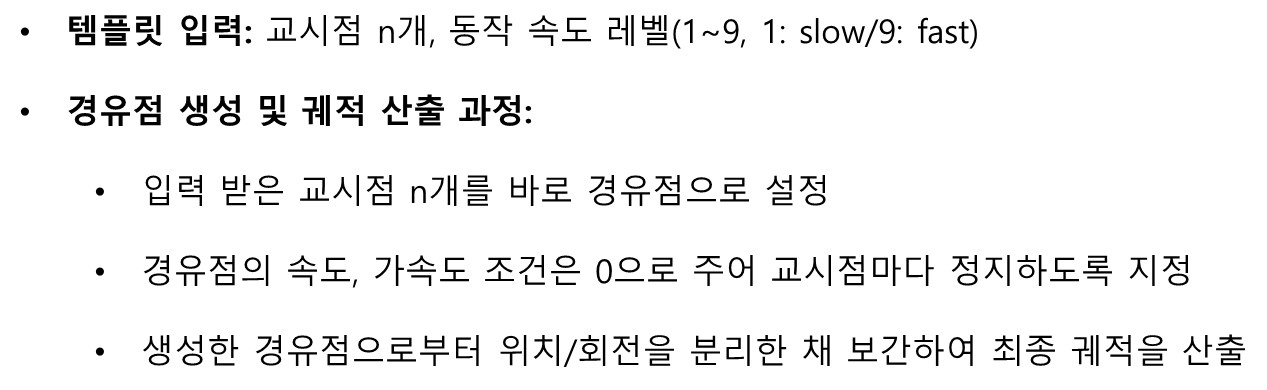

In [29]:
num = 4 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [30]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [31]:
print("궤적 중간점들 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

궤적 중간점들 입력
Press '5' button to get pos

points0 : [-186.37051, 350.07455, 521.6741, 179.99142, 18.52065, 89.991234]

points1 : [-492.2712, 360.58145, 507.39197, -157.18886, -18.192068, 106.563126]

points2 : [-272.48312, 444.22195, 391.4909, 140.96884, -5.4893723, 131.06235]

points3 : [-512.5497, 449.50067, 407.78723, -172.838, -12.868746, 117.945854]



In [32]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(num):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)


# 17번 템플릿: 교시점 사이를 왕복하는 직선

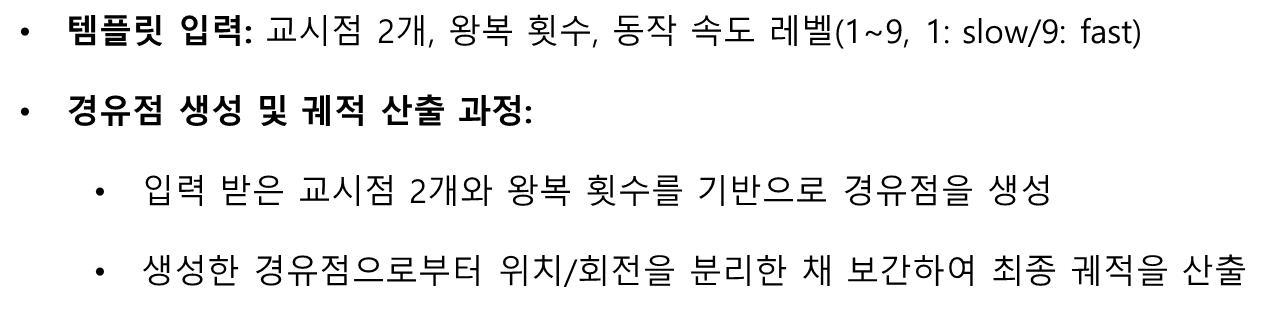

In [40]:
num = 2 # 교시점 갯수 입력
repeat_num = 3 # 왕뵥 횟수
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [41]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [42]:
print("교시점 2개 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

교시점 2개 입력
Press '5' button to get pos

points0 : [-186.45801, 350.02814, 521.5911, 179.98505, 13.831287, 90.00687]

points1 : [-394.0741, 356.82507, 419.90213, 179.93597, 13.946206, 90.30074]



In [44]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)

if repeat_num == 0:
    control.MoveL(tpos=points[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)
    control.MoveL(tpos=points[1],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
else:
    for i in range(repeat_num):
        control.MoveL(tpos=points[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
        time.sleep(0.2)
        control.MoveL(tpos=points[1],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
        time.sleep(0.2)
    control.MoveL(tpos=points[0],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)



# 18번 템플릿: 로봇 말단의 위치는 고정. 회전만 수행하는 궤적

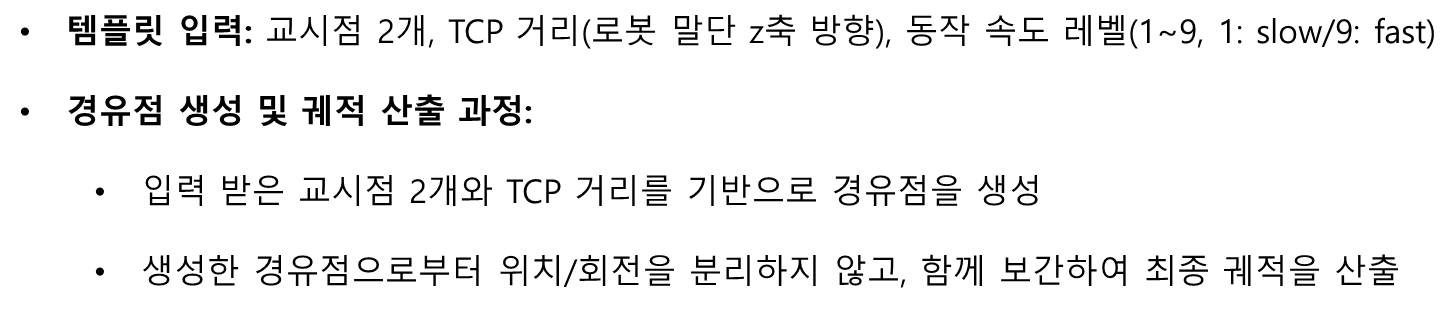

In [127]:
num = 2 # 교시점 갯수 입력
vel_ratio = 25 #동작 속도 레벨
acc_ratio = 25 # 동작 속도 레벨

points = [0]*num
points_inverZ = [0]*num

In [128]:
def get_pos():
    p = rtde.GetControlData()['p'] # task pos
    target_pos = list(p)
    # 교시점의 회전 성분 z축을 로봇 베이스 좌표 기준으로 z축으로 정렬
    # -z축으로 정렬.
    target_pos_inverZ = list(target_pos)
    target_pos_inverZ[5] = -target_pos_inverZ[5] 
    return target_pos, target_pos_inverZ

In [129]:
print("교시점 2개 입력")
print("Press '5' button to get pos\n")
for i in range (num):
    while True:
#         clear_output(wait=True)
        time.sleep(1)
    #     time.sleep(0.01)
        key = keyboard.read_key()
        if key == "5":
            break
            key = False
    points[i], points_inverZ = get_pos()
    if i == 0:
        init_jpos = rtde.GetControlData()['q']
    print(f"points{i} : {points[i]}\n")

교시점 2개 입력
Press '5' button to get pos

points0 : [-358.4008, -196.82045, 525.2019, -178.98407, -0.98689455, 179.99446]

points1 : [-392.03964, -155.3196, 500.2161, -179.05292, 2.8905764, 173.74335]



In [131]:
control.MoveJ(jpos=init_jpos, blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
time.sleep(0.2)
for i in range(num):
    control.MoveL(tpos=points[i],blending_type=common.Property.BlendingType.RADIUS, vel_ratio=vel_ratio, acc_ratio=acc_ratio)
    time.sleep(0.2)